# RQ2 - Durable poisoning via the never-evict exemplar memory

In [ ]:
import os, sys, copy
from typing import Callable

sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.experiments.contrastive_ncm import (
    load_cicids2017,
    prepare_temporal_split,
    BaseLearnerMLP,
    eval_base_learner,
    AdaptiveDAdaptiveM,
    run_stream,
    initial_training,
    apply_paper_style,
    save_fig,
    save_latex,
    agg,
    set_progress,
    set_stream_verbose,
    DAY_NAMES_DEFAULT,
)
from src.detectors.contrastive_ncm import ContrastiveNCMDetector

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')

DATA_DIR = os.path.abspath('../../data/CICIDS2017_Engelen')
FIGURE_DIR = os.path.abspath('./figures')
TABLE_DIR = os.path.abspath('./tables')

NOVEL_CLASSES = ['DoS', 'PortScan']
POISON_TARGET = 'DoS'
CONCEPT_BATCH = 256
BATCH_SIZE = 1_000
DD_RETRAIN_EPOCHS = 300
DD_RETRAIN_LR = 1e-4
DD_EVAL_POOL_N = 2000
M_HIDDEN = (256, 128, 64)

POISON_FRAC = 0.20
N_SEEDS = 3
SEEDS = [RANDOM_SEED + 1000 + i for i in range(N_SEEDS)]

PROGRESS = False
set_progress(PROGRESS)
set_stream_verbose(PROGRESS)

apply_paper_style()
DAY_NAMES = DAY_NAMES_DEFAULT

/home/azureuser/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and preprocess

In [ ]:
print('Loading CICIDS2017...')
data = load_cicids2017(DATA_DIR)
split = prepare_temporal_split(
    data, novel_classes=NOVEL_CLASSES, per_class_metric_names=NOVEL_CLASSES, random_seed=RANDOM_SEED
)
print(f'Rows {len(data.X):,}  Known {split.n_known}  Stream {len(split.X_stream):,}')

target_id = int(data.le_full.transform([POISON_TARGET])[0])
dos_pool = data.X[data.y_all == target_id].astype(np.float32)
print(f'{POISON_TARGET} poison pool: {len(dos_pool):,} flows')

batch_days = split.d_stream[::BATCH_SIZE]
POISON_UNTIL = int(np.argmax(batch_days >= 3))
print(f'Poison window = batches [0, {POISON_UNTIL}) (Mon-Wed); clean thereafter (Thu-Fri).')

Loading CICIDS2017...


Rows 2,100,814  Known 7  Stream 763,401
DoS poison pool: 171,779 flows
Poison window = batches [0, 421) (Mon-Wed); clean thereafter (Thu-Fri).


## Initial training and system builders

In [ ]:
print('Initial training...')
init = initial_training(
    X_tr=split.X_tr, y_tr_mc=split.y_tr_mc, y_tr_bin=split.y_tr_bin,
    n_known=split.n_known, input_dim=data.input_dim, device=DEVICE, random_seed=RANDOM_SEED,
)
print(f'drift_threshold={init.drift_threshold:.4f}  T={init.concept_threshold:.4f}')

_rng_pool = np.random.default_rng(RANDOM_SEED + 7)
X_dd_eval_pool = split.novel_pool[_rng_pool.choice(len(split.novel_pool), DD_EVAL_POOL_N, replace=False)]

def _fresh_detector():
    det = ContrastiveNCMDetector(
        input_dim=data.input_dim, hidden_dim=64, latent_dim=32, temperature=0.1, device=DEVICE
    )

    det.autoencoder.load_state_dict(copy.deepcopy(init.dd_init_ae))
    det.ncm = copy.deepcopy(init.dd_init_ncm)
    det.drift_threshold = init.drift_threshold
    det.concept_threshold = init.concept_threshold
    det.num_classes = split.n_known
    det._reset_drift_buffer()

    return det

def _fresh_m():
    ml = BaseLearnerMLP(data.input_dim, M_HIDDEN).to(DEVICE)
    ml.load_state_dict(copy.deepcopy(init.m_init_state))
    return ml

def fresh_full_system(n_exemplars=500):
    sys_ = AdaptiveDAdaptiveM(
        detector=_fresh_detector(), base_learner=_fresh_m(),
        X_exemplars=init.X_exemplars, y_exemplars=init.y_exemplars, y_exemplars_mc=init.y_exemplars_mc,
        m_init_state=init.m_init_state, X_eval=split.X_eval, y_eval_bin=split.y_eval_bin,
        novel_mask=split.novel_mask_eval, X_dd_eval_pool=X_dd_eval_pool, per_class_masks=split.per_class_masks,
        concept_batch=CONCEPT_BATCH, dd_retrain_epochs=DD_RETRAIN_EPOCHS, dd_retrain_lr=DD_RETRAIN_LR,
        X_cal=init.X_cal, y_cal_mc=init.y_cal_mc,
    )

    sys_.NOVEL_EXEMPLARS_PER_CONCEPT = n_exemplars
    return sys_


Initial training...


    [Contrastive 20/300] loss=0.1477


    [Contrastive 40/300] loss=0.0835


    [Contrastive 60/300] loss=0.0492


    [Contrastive 80/300] loss=0.0359


...

    [M 40/100] loss=0.0004


    [M 60/100] loss=0.0002


    [M 80/100] loss=0.0002


    [M 100/100] loss=0.0005


drift_threshold=1.3339  T=37.8378


In [ ]:
FNR_KEY = f'fnr_{POISON_TARGET.lower().replace(" ", "_")}'

def sustained(p):
    return lambda b: p

def poison_then_clean(p):
    return lambda b: p if b < POISON_UNTIL else 0.0

def run_condition(seed, schedule_fn, poison_frac, inject_label, pool, n_exemplars):
    torch.manual_seed(seed)
    np.random.seed(seed)

    sys_ = fresh_full_system(n_exemplars=n_exemplars)
    res = run_stream(
        sys_, X_stream=split.X_stream, y_stream_bin=split.y_stream_bin, d_stream=split.d_stream,
        novel_pool=pool, poison_frac=poison_frac, schedule_fn=schedule_fn,
        rng_seed=seed, batch_size=BATCH_SIZE, min_inject_day=1, inject_label=inject_label,
    )

    by_day = {}
    for d in range(5):
        vals = [r.extras[FNR_KEY] for r in res
                if r.day_idx == d and FNR_KEY in r.extras and not np.isnan(r.extras[FNR_KEY])]
        by_day[d] = float(np.mean(vals)) if vals else float('nan')

    mem_y = sys_.novel_y
    n_mem = 0 if mem_y is None else int(len(mem_y))
    n_poison = 0 if mem_y is None else int((np.asarray(mem_y) == 0).sum())
    
    return {
        'by_day': by_day,
        'fri_fnr': by_day[4],
        'dd_retrains': int(getattr(sys_, 'n_dd_retrains', 0)),
        'mem_total': n_mem,
        'mem_poison': n_poison,
    }


## Experiment 1: clean / sustained / poison-then-clean

In [ ]:
CONDITIONS = {
    'clean':             dict(schedule_fn=None,                          poison_frac=0.0, inject_label=0, pool=split.novel_pool, n_exemplars=500),
    'sustained poison':  dict(schedule_fn=sustained(POISON_FRAC),        poison_frac=0.0, inject_label=0, pool=dos_pool,         n_exemplars=500),
    'poison-then-clean': dict(schedule_fn=poison_then_clean(POISON_FRAC), poison_frac=0.0, inject_label=0, pool=dos_pool,        n_exemplars=500),
}

exp1 = {name: [] for name in CONDITIONS}
for name, cfg in CONDITIONS.items():
    print(f"========== {name} ==========")

    for seed in SEEDS:
        r = run_condition(seed=seed, **cfg)
        exp1[name].append(r)
        
        print(f'seed {seed}: Fri FNR({POISON_TARGET})={r["fri_fnr"]:.3f}  DD-retr={r["dd_retrains"]}  '
              f'mem poison={r["mem_poison"]}/{r["mem_total"]}')

========== clean ==========


    [M 20/100] loss=0.0021


    [M 40/100] loss=0.0010


    [M 60/100] loss=0.0010


    [M 80/100] loss=0.0004


...

    [Contrastive 160/300] loss=3.9054
    [Contrastive 180/300] loss=3.5475


    [Contrastive 200/300] loss=3.1122
    [Contrastive 220/300] loss=2.7484


    [Contrastive 240/300] loss=2.3544
    [Contrastive 260/300] loss=2.0172


    [Contrastive 280/300] loss=1.7907
    [Contrastive 300/300] loss=1.6329


seed 1044: Fri FNR(DoS)=0.032  DD-retr=2  mem poison=649/1000


## Experiment 2: exemplar-accumulation ablation (the mechanism)

In [ ]:
exp2 = {}
for n_ex in (500, 0):
    name = f'poison-then-clean (accum={n_ex})'
    exp2[name] = []
    print(f'========== {name} ==========')

    for seed in SEEDS:
        r = run_condition(seed=seed, schedule_fn=poison_then_clean(POISON_FRAC),
                          poison_frac=0.0, inject_label=0, pool=dos_pool, n_exemplars=n_ex)
        exp2[name].append(r)

        print(f'seed {seed}: Fri FNR({POISON_TARGET})={r["fri_fnr"]:.3f}  DD-retr={r["dd_retrains"]}  '
              f'mem poison={r["mem_poison"]}/{r["mem_total"]}')


========== poison-then-clean (accum=500) ==========


    [M 20/100] loss=0.5240


    [M 40/100] loss=0.5242


    [M 60/100] loss=0.5245


    [M 80/100] loss=0.5231


...

    [Contrastive 160/300] loss=1.7701
    [Contrastive 180/300] loss=1.7698


    [Contrastive 200/300] loss=1.5590
    [Contrastive 220/300] loss=1.6221


    [Contrastive 240/300] loss=1.5369
    [Contrastive 260/300] loss=1.3531


    [Contrastive 280/300] loss=1.1978
    [Contrastive 300/300] loss=1.1144


seed 1044: Fri FNR(DoS)=0.077  DD-retr=2  mem poison=0/0


## Results

,Fri FNR(DoS),DD retrains,Poison in memory
Condition,,,
clean,0.013 ± 0.002,2.333 ± 1.247,359/1333
sustained poison,0.589 ± 0.413,0.333 ± 0.471,53/167
poison-then-clean,0.033 ± 0.001,2.000 ± 0.000,634/1000
poison-then-clean (accum=500),0.033 ± 0.001,2.000 ± 0.000,634/1000
poison-then-clean (accum=0),0.041 ± 0.029,1.667 ± 0.471,0/0


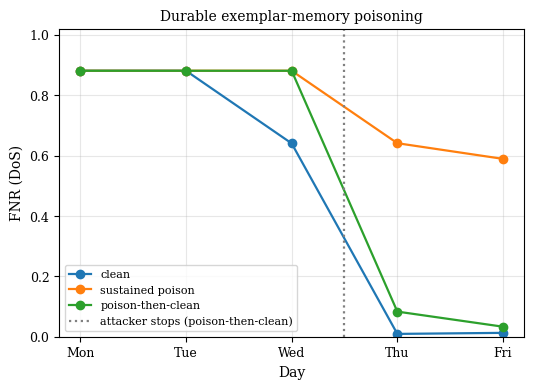

In [ ]:
rows = []
for name, runs in {**exp1, **exp2}.items():
    fri = [r['fri_fnr'] for r in runs]
    mem_p = [r['mem_poison'] for r in runs]
    mem_t = [r['mem_total'] for r in runs]
    rows.append({
        'Condition': name,
        f'Fri FNR({POISON_TARGET})': agg(fri),
        'DD retrains': agg([float(r['dd_retrains']) for r in runs]),
        'Poison in memory': f'{np.mean(mem_p):.0f}/{np.mean(mem_t):.0f}',
    })
    
summary = pd.DataFrame(rows).set_index('Condition')

display(summary)
save_latex(summary, 'rq2_durable_poison.tex', TABLE_DIR,
           caption='Durable poisoning of the never-evict exemplar memory. Benign-labelled '
                   f'{POISON_TARGET} flows are injected (sustained, or poison-then-clean) and harvested into '
                   'the accumulated exemplar set, then replayed at every rebuild. End-of-stream (Friday) '
                   f'false-negative rate on {POISON_TARGET}, mean +/- std over three seeds; "poison in memory" '
                   'is the benign-labelled count harvested into the never-evict exemplar set. The accum=0 row '
                   'disables the memory, isolating it as the persistence vector.',
           label='tab:rq2-durable-poison')


fig, ax = plt.subplots(figsize=(6, 4))
for name in ['clean', 'sustained poison', 'poison-then-clean']:
    by_day_mean = [np.nanmean([runs['by_day'][d] for runs in exp1[name]]) for d in range(5)]
    ax.plot(range(5), by_day_mean, 'o-', label=name)
ax.axvline(2.5, color='grey', ls=':', label='attacker stops (poison-then-clean)')
ax.set_xticks(range(5)); ax.set_xticklabels(DAY_NAMES)
ax.set_ylabel(f'FNR ({POISON_TARGET})'); ax.set_xlabel('Day'); ax.set_ylim(0, 1.02)
ax.set_title('Durable exemplar-memory poisoning'); ax.legend()
save_fig(fig, 'rq2_durable_poison', FIGURE_DIR)
plt.show()